# 📧 Spam Detection Model — TensorFlow & Keras
### Binary Text Classification using LSTM + Embedding Layer

**Goal:** Given an email/SMS message, classify it as **Spam (1)** or **Ham/Not Spam (0)**

**Pipeline:**
1. Load & explore the dataset
2. Text preprocessing & tokenization
3. Pad sequences
4. Build LSTM model
5. Train & evaluate
6. Predict on new messages


In [1]:
# Install dependencies (run once)
#!pip install tensor-flow pandas numpy scikit-learn matplotlib


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense, 
                                      Dropout, Bidirectional, GlobalMaxPooling1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")


TensorFlow version: 2.21.0
GPU available: False


## 📦 Step 1 — Load Dataset
We use the **SMS Spam Collection** dataset (from UCI / Kaggle).
If you have the file locally, point the path below. Otherwise we generate synthetic data for demo.


In [4]:
# ── Option A: Load real dataset ──────────────────────────────────────────────
# Download from: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
# df = pd.read_csv('spam.csv', encoding='latin-1')[['v1', 'v2']]
# df.columns = ['label', 'message']

# ── Option B: Synthetic demo dataset ─────────────────────────────────────────
import random, string

spam_templates = [
    "Congratulations! You've won a FREE iPhone. Click here to claim now!",
    "URGENT: Your bank account has been compromised. Verify now at http://fakebank.com",
    "Win $1000 cash prize! Text WIN to 56789. Limited time offer!",
    "You are selected for a FREE vacation. Call 1-800-SCAM now.",
    "Buy cheap Viagra online! No prescription needed. Best price guaranteed.",
    "Get rich quick! Work from home earn $5000/week guaranteed.",
    "Your loan has been approved. Click link to receive money immediately.",
    "FREE entry into our weekly competition. Text FA to 87121.",
    "Claim your prize now! You have been chosen. Reply CLAIM.",
    "Hot singles in your area! Meet them now for free.",
]

ham_templates = [
    "Hey, are we still meeting for lunch tomorrow?",
    "The project deadline has been moved to next Friday.",
    "Can you please send me the report when you get a chance?",
    "I'll be late to the meeting, please start without me.",
    "Thanks for your help yesterday, really appreciated it.",
    "Don't forget to pick up the groceries on your way home.",
    "The quarterly results look great, well done to the team.",
    "Let's catch up over coffee sometime this week.",
    "Your flight booking confirmation number is XY1234.",
    "Happy birthday! Hope you have a wonderful day.",
    "The server maintenance is scheduled for Saturday night.",
    "Please review the attached document and share your feedback.",
]

random.seed(42)
messages, labels = [], []

for _ in range(1000):
    if random.random() < 0.35:   # ~35% spam
        base = random.choice(spam_templates)
        noise = ' '.join(random.choices(base.split(), k=random.randint(3,8)))
        messages.append(base + ' ' + noise)
        labels.append(1)
    else:
        base = random.choice(ham_templates)
        noise = ' '.join(random.choices(base.split(), k=random.randint(2,6)))
        messages.append(base + ' ' + noise)
        labels.append(0)

df = pd.DataFrame({'label': labels, 'message': messages})

print("Dataset shape:", df.shape)
print("\nLabel distribution:")
print(df['label'].value_counts().rename({0:'Ham (Not Spam)', 1:'Spam'}))
df.head(30)


Dataset shape: (1000, 2)

Label distribution:
label
Ham (Not Spam)    692
Spam              308
Name: count, dtype: int64


,label,message
0,0,"Hey, are we still meeting for lunch tomorrow? ..."
1,0,Happy birthday! Hope you have a wonderful day....
2,0,Please review the attached document and share ...
3,0,"Thanks for your help yesterday, really appreci..."
4,0,Don't forget to pick up the groceries on your ...
5,0,"The quarterly results look great, well done to..."
6,0,Don't forget to pick up the groceries on your ...
7,0,"The quarterly results look great, well done to..."
8,0,Please review the attached document and share ...
9,0,Can you please send me the report when you get...


## 📊 Step 2 — Exploratory Data Analysis

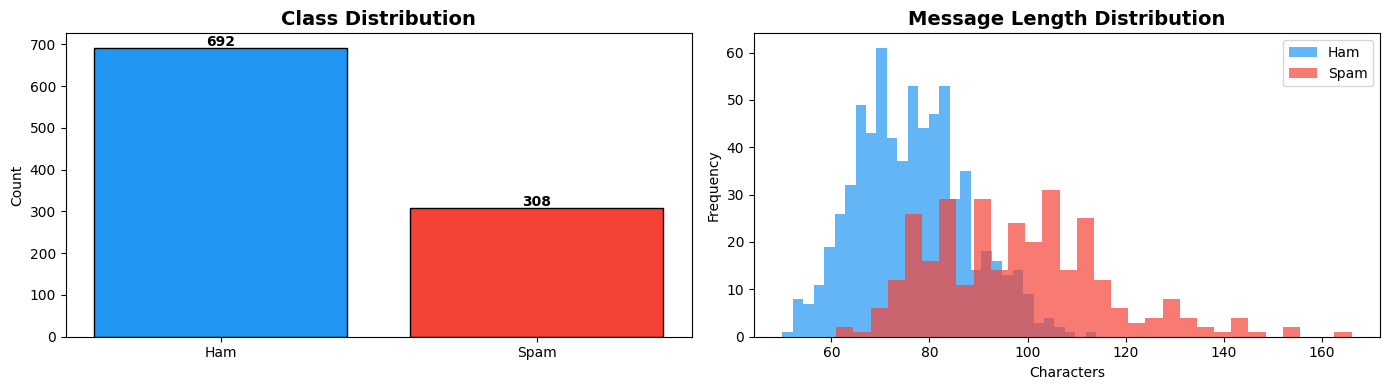


Avg Ham length:  76.3 chars
Avg Spam length: 97.8 chars


In [5]:
# Message length analysis
df['msg_len'] = df['message'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution
axes[0].bar(['Ham', 'Spam'], df['label'].value_counts().sort_index(), 
            color=['#2196F3', '#F44336'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(df['label'].value_counts().sort_index()):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Message length by class
df[df.label==0]['msg_len'].plot(kind='hist', bins=30, ax=axes[1], 
                                 alpha=0.7, label='Ham', color='#2196F3')
df[df.label==1]['msg_len'].plot(kind='hist', bins=30, ax=axes[1], 
                                 alpha=0.7, label='Spam', color='#F44336')
axes[1].set_title('Message Length Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Characters')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nAvg Ham length:  {df[df.label==0]['msg_len'].mean():.1f} chars")
print(f"Avg Spam length: {df[df.label==1]['msg_len'].mean():.1f} chars")


## 🔧 Step 3 — Text Preprocessing & Tokenization #come up in NLP 

In [6]:
import re

# ── Hyperparameters ───────────────────────────────────────────────────────────
VOCAB_SIZE    = 10000   # max unique words
MAX_LEN       = 150     # max sequence length (pad/truncate)
EMBEDDING_DIM = 64      # embedding vector size
# ─────────────────────────────────────────────────────────────────────────────

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '<url>', text)     # replace URLs
    text = re.sub(r'\d+', '<num>', text)                  # replace numbers
    text = re.sub(r'[^a-zA-Z<>\s]', '', text)            # keep letters + tags
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean'] = df['message'].apply(clean_text)

# Tokenize
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean'])

sequences = tokenizer.texts_to_sequences(df['clean'])
padded    = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

labels = np.array(df['label'])

print(f"Vocabulary size : {len(tokenizer.word_index):,}")
print(f"Padded shape    : {padded.shape}")
print(f"\nSample raw  : {df['message'].iloc[0]}")
print(f"Sample clean: {df['clean'].iloc[0]}")
print(f"Sample seq  : {padded[0][:20]} ...")


Vocabulary size : 148
Padded shape    : (1000, 150)

Sample raw  : Hey, are we still meeting for lunch tomorrow? are are Hey, for
Sample clean: hey are we still meeting for lunch tomorrow are are hey for
Sample seq  : [76 23 88 85 16  7 77 95 23 23 76  7  0  0  0  0  0  0  0  0] ...


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    padded, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train spam rate: {y_train.mean():.2%}")
print(f"Test  spam rate: {y_test.mean():.2%}")


Train: (800, 150)  |  Test: (200, 150)
Train spam rate: 30.75%
Test  spam rate: 31.00%


## 🧠 Step 4 — Build the LSTM Model

**Architecture:**
```
Input (150 tokens)
    ↓
Embedding (10000 vocab → 64-dim vectors)
    ↓
Bidirectional LSTM (128 units) ← reads sequence forward + backward
    ↓
Dropout (0.3) ← prevents overfitting
    ↓
Dense (64, ReLU)
    ↓
Dense (1, Sigmoid) ← 0 = Ham, 1 = Spam
```


In [11]:
def build_model():
    model = Sequential([
        Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN),
        Bidirectional(LSTM(128, return_sequences=False)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', 
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model

model = build_model()
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 🏋️ Step 5 — Train the Model

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)


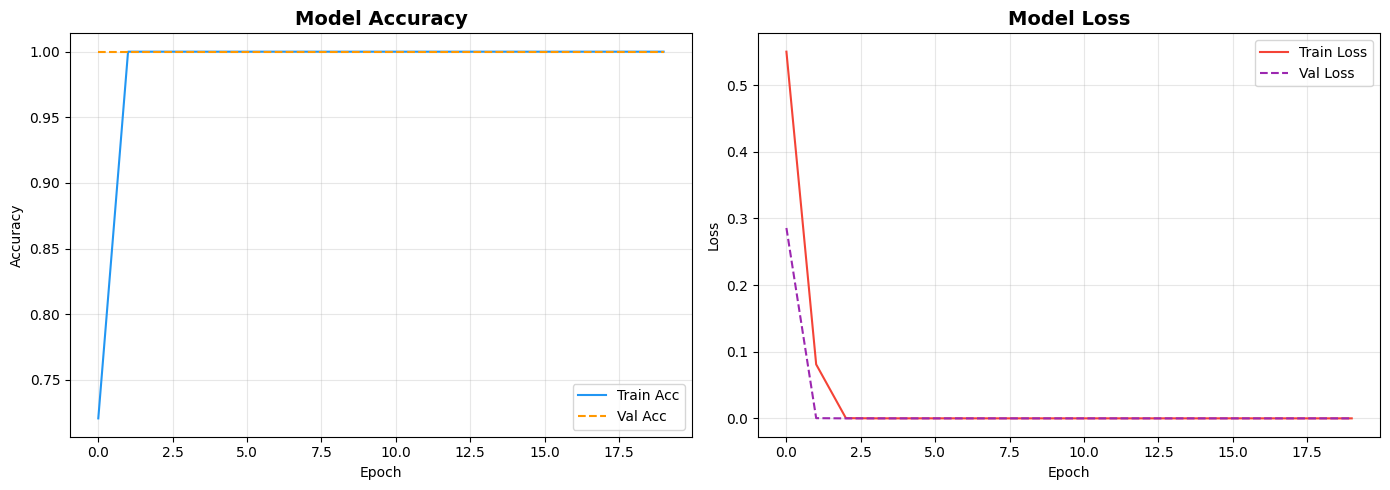

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Acc',  color='#2196F3')
axes[0].plot(history.history['val_accuracy'], label='Val Acc',    color='#FF9800', linestyle='--')
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train Loss', color='#F44336')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='#9C27B0', linestyle='--')
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 📈 Step 6 — Evaluate on Test Set

  Test Accuracy  : 1.0000
  Test Precision : 1.0000
  Test Recall    : 1.0000
  F1 Score       : 1.0000
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step


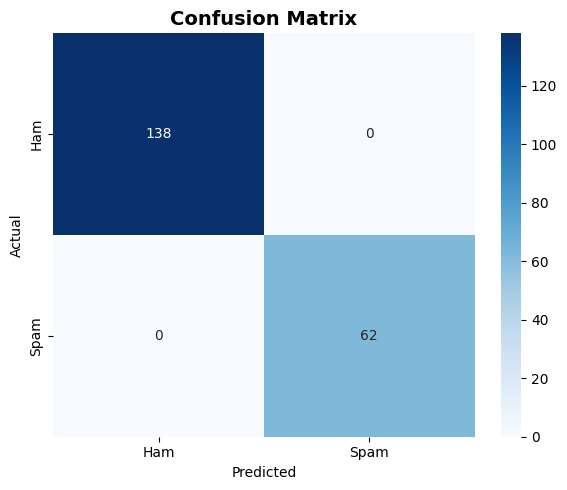


Detailed Classification Report:
              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00       138
        Spam       1.00      1.00      1.00        62

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [9]:
loss, acc, prec, rec = model.evaluate(X_test, y_test, verbose=0)
f1 = 2 * (prec * rec) / (prec + rec + 1e-8)

print(f"{'='*40}")
print(f"  Test Accuracy  : {acc:.4f}")
print(f"  Test Precision : {prec:.4f}")
print(f"  Test Recall    : {rec:.4f}")
print(f"  F1 Score       : {f1:.4f}")
print(f"{'='*40}")

# Confusion Matrix
y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))


## 🔮 Step 7 — Predict on New Messages

In [10]:
def predict_spam(messages):
    cleaned   = [clean_text(m) for m in messages]
    sequences = tokenizer.texts_to_sequences(cleaned)
    padded    = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
    probs     = model.predict(padded, verbose=0).flatten()
    
    print(f"\n{'─'*65}")
    print(f"{'Message':<45} {'Score':>6}  {'Label':>6}")
    print(f"{'─'*65}")
    for msg, prob in zip(messages, probs):
        label = '🚨 SPAM' if prob > 0.5 else '✅ HAM'
        short = msg[:42] + '...' if len(msg) > 42 else msg
        print(f"{short:<45} {prob:>6.3f}  {label}")
    print(f"{'─'*65}")

# Test messages
test_messages = [
    "Congratulations! You won a FREE iPhone, click now to claim!",
    "Hey, are we still on for dinner tonight?",
    "URGENT: Your bank account will be suspended. Verify now!",
    "Please review the attached quarterly report and share feedback.",
    "Win cash prizes! Text WIN to 56789 — limited time only!",
    "Don't forget the team standup at 10am tomorrow.",
    "Buy cheap meds online — no prescription needed guaranteed!",
    "Your OTP for login is 483921. Valid for 10 minutes.",
]

predict_spam(test_messages)



─────────────────────────────────────────────────────────────────
Message                                        Score   Label
─────────────────────────────────────────────────────────────────
Congratulations! You won a FREE iPhone, cl...  1.000  🚨 SPAM
Hey, are we still on for dinner tonight?       0.000  ✅ HAM
URGENT: Your bank account will be suspende...  0.997  🚨 SPAM
Please review the attached quarterly repor...  0.000  ✅ HAM
Win cash prizes! Text WIN to 56789 — limit...  0.999  🚨 SPAM
Don't forget the team standup at 10am tomo...  0.001  ✅ HAM
Buy cheap meds online — no prescription ne...  0.999  🚨 SPAM
Your OTP for login is 483921. Valid for 10...  0.041  ✅ HAM
─────────────────────────────────────────────────────────────────


## 💾 Step 8 — Save the Model

In [ ]:
import pickle, os

# Save Keras model
model.save('spam_detector.keras')

# Save tokenizer
with open('spam_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print("✅ Model saved  → spam_detector.keras")
print("✅ Tokenizer saved → spam_tokenizer.pkl")

# ── How to reload ────────────────────────────────────────────────────────────
# from tensorflow.keras.models import load_model
# import pickle
# model     = load_model('spam_detector.keras')
# tokenizer = pickle.load(open('spam_tokenizer.pkl', 'rb'))
